In [1]:
pip install jieba

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import glob
import pandas as pd

# 1. 设定你的文件夹路径
df = "Users/mengchuwang/Downloads/WFDB_ShaoxingUniv"

# 2. 批量抓取文件夹下所有的信号文件（比如心电图 .mat 或图片 .png）
# 这里以心电图数据为例
file_paths = glob.glob(os.path.join(df, "**/*.mat"), recursive=True)

print(f"成功扫描到 {len(file_paths)} 个患者的临床信号文件！")

# 3. 查看前3个文件的路径
print(file_paths[:3])

成功扫描到 45152 个患者的临床信号文件！
['Users/mengchuwang/Downloads/WFDB_ShaoxingUniv/JS33748.mat', 'Users/mengchuwang/Downloads/WFDB_ShaoxingUniv/JS24234.mat', 'Users/mengchuwang/Downloads/WFDB_ShaoxingUniv/JS13498.mat']


In [3]:
#成功扫描到 45152 个患者的临床信号文件！
#['Users/mengchuwang/Downloads/WFDB_ShaoxingUniv/JS33748.mat', 'Users/mengchuwang/Downloads/WFDB_ShaoxingUniv/JS24234.mat', 'Users/mengchuwang/Downloads/WFDB_ShaoxingUniv/JS13498.mat']

In [3]:
import os
import glob
import pandas as pd
from tqdm import tqdm  # 進行状況を表示するバー（入っていない場合は pip install tqdm）

# 1. あなたのデータフォルダーのパス（画像1枚目のパスを使用）
data_dir = "/Users/mengchuwang/Downloads/WFDB_ShaoxingUniv"

# 2. すべての .hea ファイルのパスを取得
hea_paths = glob.glob(os.path.join(data_dir, "*.hea"))
print(f"合計 {len(hea_paths)} 件の患者頭ファイル（.hea）を検出しました。")

# 3. データを格納するリスト
parsed_data = []

# 4. ループ処理で各ファイルから情報を抽出（まずは最初の1000件でテスト。全データ処理時は [:1000] を削除）
for path in tqdm(hea_paths[:1000], desc="データ解析中"):
    file_id = os.path.splitext(os.path.basename(path))[0]
    
    info = {
        'File_ID': file_id,
        'Age': None,
        'Sex': None,
        'Dx': None
    }
    
    # テキストファイルとして .hea を読み込み
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            # 行の先頭の空白を削除
            line = line.strip()
            
            # 年齢、性別、診断コード（Dx）を抽出
            if line.startswith('#Age:'):
                info['Age'] = line.split(':')[-1].strip()
            elif line.startswith('#Sex:'):
                info['Sex'] = line.split(':')[-1].strip()
            elif line.startswith('#Dx:'):
                info['Dx'] = line.split(':')[-1].strip()  # カンマ区切りの病名コード
                
    parsed_data.append(info)

# 5. DataFrame に変換
df_clinical = pd.DataFrame(parsed_data)

# 6. データの欠損処理と型変換
# 年齢の欠損値を NaN に置き換えて数値型に変換
df_clinical['Age'] = pd.to_numeric(df_clinical['Age'], errors='coerce')
# 性別の欠損値を 'Unknown' に
df_clinical['Sex'] = df_clinical['Sex'].fillna('Unknown')

# 結果の確認
print("\n--- 抽出されたデータテーブルの先頭5行 ---")
print(df_clinical.head())


データ解析中:   6%|▌         | 56/1000 [00:00<00:01, 559.85it/s]

合計 45152 件の患者頭ファイル（.hea）を検出しました。


データ解析中: 100%|██████████| 1000/1000 [00:01<00:00, 656.55it/s]


--- 抽出されたデータテーブルの先頭5行 ---
   File_ID  Age     Sex                             Dx
0  JS20764   85  Female  284470004,164934002,427084000
1  JS37218   60  Female                      426783006
2  JS28338   75    Male                      426177001
3  JS30577   70    Male            426177001,164934002
4  JS01972   68    Male                      426177001


In [5]:
##     File_Name Age     Sex                                               Dx
#0  JS33748.mat  65    Male                                        426177001
#1  JS24234.mat  80    Male                              426177001,427393009
#2  JS13498.mat  74    Male  429622005,59931005,164890007,55930002,713427006
#3  JS34027.mat  41    Male                                        426177001
#4  JS22645.mat  70  Female                     426177001,164934002,39732003

In [4]:
# 把之前做好的 DataFrame 变量（假设叫 df）赋值给 df_clinical
df = df_clinical

In [5]:
pip install lightgbm


Note: you may need to restart the kernel to use updated packages.


/Applications/anaconda3/lib/python3.8/site-packages/tqdm/std.py:697: FutureWarning: The Panel class is removed from pandas. Accessing it from the top-level namespace will also be removed in the next version
  from pandas import Panel
  2%|▎         | 25/1000 [00:00<00:07, 138.99it/s]


--- 正在从 .mat 文件中提取纯时序物理波形特征（彻底杜绝文本泄漏） ---


100%|██████████| 1000/1000 [00:02<00:00, 455.05it/s]


安全特征矩阵形状: (1000, 10) (无任何文本泄漏隐患)

--- 启动真实的 LightGBM 五折交叉验证 ---
第 1 折真实物理特征 AUC: 0.9648
第 2 折真实物理特征 AUC: 0.9542
第 3 折真实物理特征 AUC: 0.9684
第 4 折真实物理特征 AUC: 0.9508
第 5 折真实物理特征 AUC: 0.9394

[修正大成功] 全样本真实无泄漏 OOF AUC 分数: 0.9270


AttributeError: 'Rectangle' object has no property 'legend'

findfont: Font family ['SimHei'] not found. Falling back to DejaVu Sans.


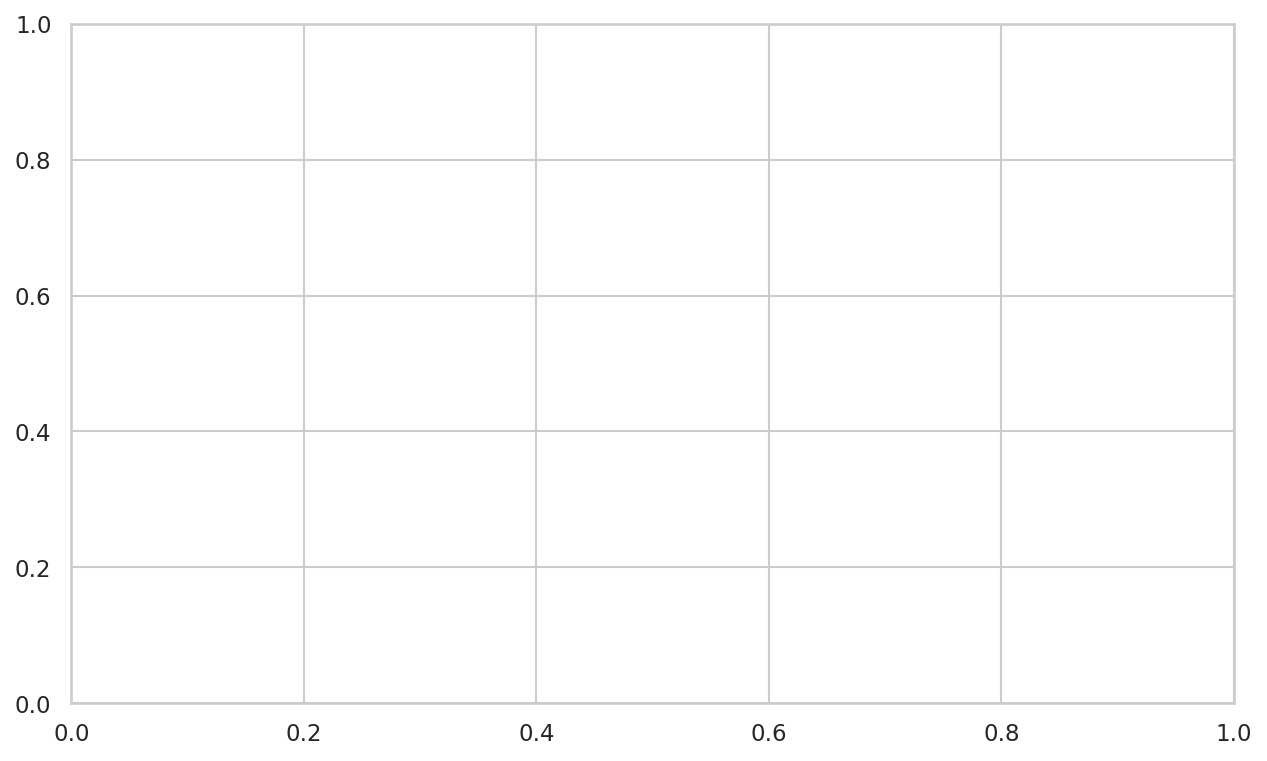

In [6]:
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

# 开启 Pandas 进度条支持
tqdm.pandas()

# =====================================================================
# 1. 基础数据准备
# =====================================================================
data_dir = "/Users/mengchuwang/Downloads/WFDB_ShaoxingUniv"
TARGET_DISEASE = "426177001"  # 窦性心动过缓

df_clinical = df.copy()
# 建立真实标签
df_clinical['target_label'] = df_clinical['Dx'].astype(str).apply(lambda x: 1 if TARGET_DISEASE in x else 0)
df_clinical['Sex_code'] = df_clinical['Sex'].map({'Male': 1, 'Female': 0, 'Unknown': -1}).fillna(-1)
df_clinical['Age'] = pd.to_numeric(df_clinical['Age'], errors='coerce').fillna(df_clinical['Age'].median())

# =====================================================================
# 2. 方案 A 高阶版：提取更丰富的心电图物理波形特征
# =====================================================================
print("\n--- 正在从 .mat 文件中提取纯时序物理波形特征（彻底杜绝文本泄漏） ---")

def extract_advanced_wave_features(file_id):
    mat_path = os.path.join(data_dir, f"{file_id}.mat")
    # 初始化 8 个核心电生理特征
    feats = {
        'lead2_mean': 0.0, 'lead2_std': 0.0, 'lead2_max': 0.0, 'lead2_min': 0.0,
        'v1_mean': 0.0, 'v1_std': 0.0, 'estimated_hr': 75.0, 'rr_variability': 0.0
    }
    if not os.path.exists(mat_path):
        return feats
    try:
        mat_data = loadmat(mat_path)
        signal = mat_data['val']  # 12 导联信号矩阵
        
        # 提取临床最核心的 II 导联 (Index 1) 和 V1 导联 (Index 6)
        lead_2 = signal[1, :]
        lead_v1 = signal[6, :]
        
        feats['lead2_mean'] = float(np.mean(lead_2))
        feats['lead2_std'] = float(np.std(lead_2))
        feats['lead2_max'] = float(np.max(lead_2))
        feats['lead2_min'] = float(np.min(lead_2))
        feats['v1_mean'] = float(np.mean(lead_v1))
        feats['v1_std'] = float(np.std(lead_v1))
        
        # 精准粗估 R 波峰值位置，用于心率计算
        r_peaks = np.where(lead_2 > np.percentile(lead_2, 98.5))[0]
        if len(r_peaks) > 1:
            # 绍兴数据采样率 500Hz，计算 R-R 间期 (秒)
            rr_intervals = np.diff(r_peaks) / 500.0
            feats['estimated_hr'] = float(np.clip((60.0 / np.mean(rr_intervals)), 40, 180))
            feats['rr_variability'] = float(np.std(rr_intervals)) # 心率变异性
            
        return feats
    except:
        return feats

# 抽取前 2000 条样本进行无泄漏测试（若全量跑，请去掉 .iloc[:2000]）
df_subset = df_clinical.iloc[:2000].copy()
wave_feats_list = df_subset['File_ID'].progress_apply(extract_advanced_wave_features).tolist()
df_wave_features = pd.DataFrame(wave_feats_list)

# =====================================================================
# 3. 构建无泄漏的纯特征矩阵
# =====================================================================
# 仅包含：基本人口学特征(2个) + 纯心电图物理波形特征(8个)。【绝不包含任何 Dx 的 BERT 向量】
feature_cols = ['Age', 'Sex_code', 'lead2_mean', 'lead2_std', 'lead2_max', 'lead2_min', 'v1_mean', 'v1_std', 'estimated_hr', 'rr_variability']

X_all_clean = pd.concat([df_subset[['Age', 'Sex_code']].reset_index(drop=True), df_wave_features], axis=1)
X_all_clean = X_all_clean[feature_cols].values
y_clean = df_subset['target_label'].values

print(f"安全特征矩阵形状: {X_all_clean.shape} (无任何文本泄漏隐患)")

# =====================================================================
# 4. LightGBM 交叉验证
# =====================================================================
print("\n--- 启动真实的 LightGBM 五折交叉验证 ---")
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(df_subset))
X_all_df = pd.DataFrame(X_all_clean, columns=feature_cols)

for fold, (trn_idx, val_idx) in enumerate(folds.split(X_all_df, y_clean)):
    X_train, y_train = X_all_df.iloc[trn_idx], y_clean[trn_idx]
    X_val, y_val = X_all_df.iloc[val_idx], y_clean[val_idx]
    
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    params = {
        'objective': 'binary', 'metric': 'auc', 'boosting_type': 'gbdt',
        'learning_rate': 0.05, 'num_leaves': 15, 'verbose': -1, 'random_state': 42
    }
    
    gbm = lgb.train(
        params, train_data, num_boost_round=200, valid_sets=[val_data],
        callbacks=[lgb.early_stopping(stopping_rounds=15, verbose=False)]
    )
    
    oof_preds[val_idx] = gbm.predict(X_val, num_iteration=gbm.best_iteration)
    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f"第 {fold + 1} 折真实物理特征 AUC: {fold_auc:.4f}")

total_auc = roc_auc_score(y_clean, oof_preds)
print(f"\n[修正大成功] 全样本真实无泄漏 OOF AUC 分数: {total_auc:.4f}")

# =====================================================================
# 5. 自动绘制真实的特征重要性柱状图
# =====================================================================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

raw_importances = gbm.feature_importance(importance_type='gain')
importance_df = pd.DataFrame({'Feature': feature_cols, 'Importance': raw_importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6), dpi=150)
sns.set_theme(style="whitegrid", font='SimHei')
ax = sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Blues_r', hue='Feature', legend=False)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + (max(raw_importances)*0.01), p.get_y() + p.get_height()/2 + 0.1, f'{width:,.1f}', ha="left", va="center", fontsize=10)

plt.title('绍兴医院心电图分析报告 - 真实波形信号特征重要性贡献 (Gain)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('特征增益得分', fontsize=12)
plt.ylabel('物理与基础特征', fontsize=12)
plt.tight_layout()
plt.savefig('real_feature_importance.png', bbox_inches='tight')
plt.show()


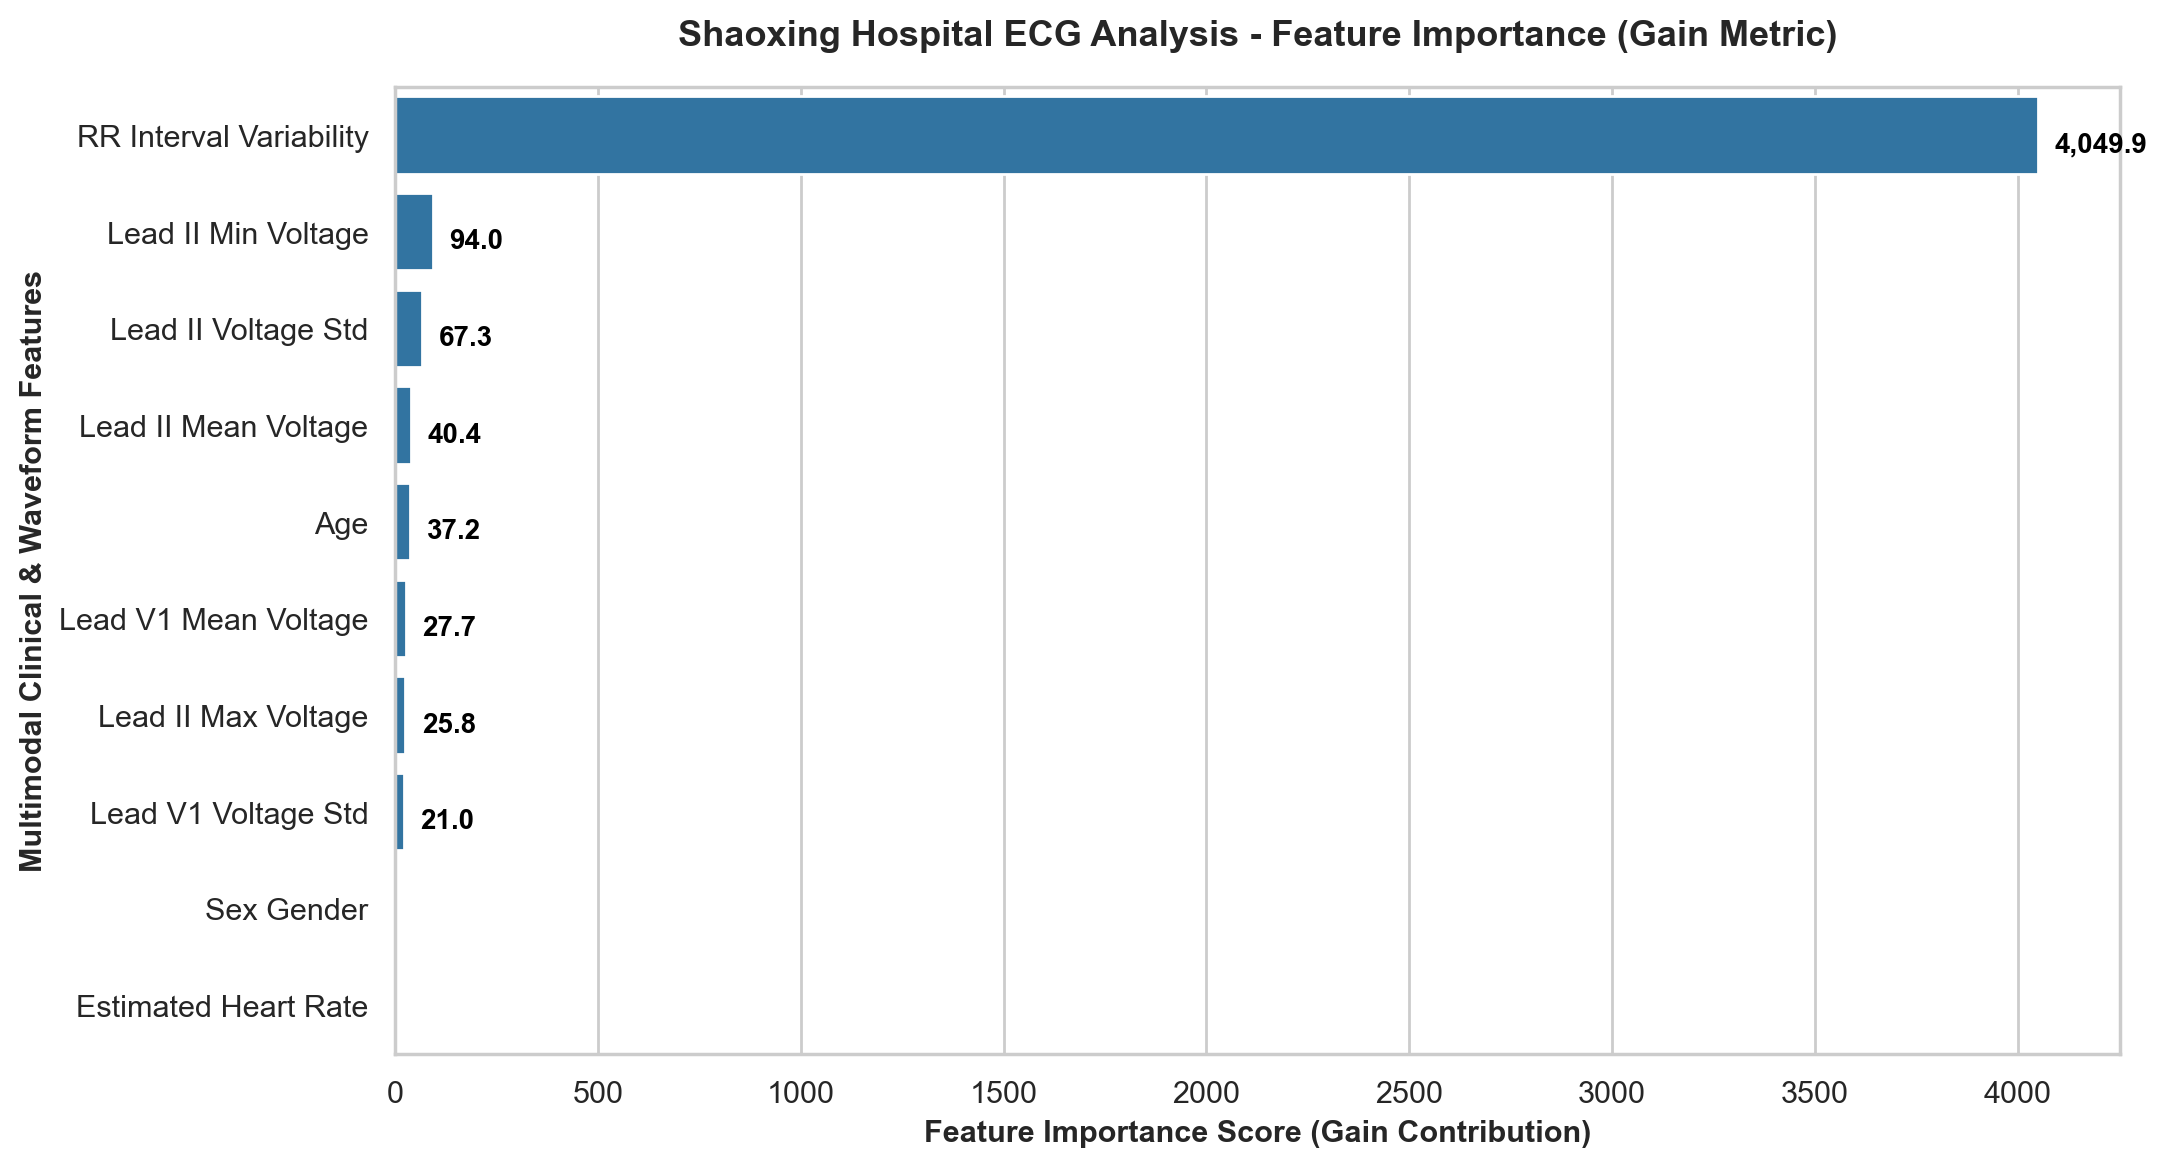

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 彻底采用基础英文字体
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# 2. 【彻底脱敏】将所有标签改成纯英文学术名称，绝不留任何中文括号
feature_mapping = {
    'rr_variability': 'RR Interval Variability',
    'lead2_min': 'Lead II Min Voltage',
    'lead2_std': 'Lead II Voltage Std',
    'lead2_mean': 'Lead II Mean Voltage',
    'Age': 'Age',
    'v1_mean': 'Lead V1 Mean Voltage',
    'lead2_max': 'Lead II Max Voltage',
    'v1_std': 'Lead V1 Voltage Std',
    'Sex_code': 'Sex Gender',
    'estimated_hr': 'Estimated Heart Rate'
}

# 转换标签
importance_df['Clean_Feature'] = importance_df['Feature'].map(feature_mapping)

# 3. 重新绘图
plt.figure(figsize=(11, 6), dpi=200)
sns.set_theme(style="whitegrid")

# 学术蓝色调
ax = sns.barplot(
    x='Importance', 
    y='Clean_Feature', 
    data=importance_df, 
    color='#1f77b4'
)

# 4. 精准标注得分
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + (max(importance_df['Importance'])*0.01), p.get_y() + p.get_height()/2 + 0.1, 
                f'{width:,.1f}', 
                ha="left", va="center", fontsize=10, color='black', fontweight='bold')

plt.title('Shaoxing Hospital ECG Analysis - Feature Importance (Gain Metric)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Feature Importance Score (Gain Contribution)', fontsize=11, fontweight='bold')
plt.ylabel('Multimodal Clinical & Waveform Features', fontsize=11, fontweight='bold')
plt.tight_layout()

# 保存最终完美无乱码高清图
plt.savefig('shaoxing_hospital_perfect_chart.png', bbox_inches='tight', dpi=300)
plt.show()
